# A/B testing in a marketplace — does a product page redesign increase AOV?

**Portfolio project · CRISP-DM methodology · Brazilian E-Commerce by Olist dataset**

This notebook is the **presentation layer**: it reads the results generated by the pipeline and tells
the story. **It computes nothing.** All the computation lives in `src/` and is run with a single
command:

```bash
python run_all.py      # ~5 min, fixed seeds -> deterministic result
```

`run_all.py` runs the 6 CRISP-DM phases in order, verifies each output and finishes with a
reproducibility report. This notebook assumes it has already been run.

> **Note on methodological honesty.** The Olist dataset does not come with control/treatment
> groups. The assignment is **simulated** and the treatment effect is **injected in a declared
> way** (diluted model: 20% of the treated units respond with +25%, mean effect +5%). The goal is
> **not** to discover whether the redesign works — we know it does, because we are the ones who
> put the effect there — but to **demonstrate that the design and the analysis control false
> positives and recover an effect of known size without bias**. That is the competency being
> assessed in an experimentation role.

In [1]:
import json
import os
import sys
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path.insert(0, "src")

import pandas as pd
from IPython.display import Image, display

import config

TABLES = config.OUT_TABLES
FIGURES = config.OUT_FIGURES


def rj(name):
    return json.loads((TABLES / name).read_text(encoding="utf-8"))


def L(x):
    return [round(float(v), 3) for v in x]


_needed = ["fase2_resumen.json", "fase3_balance.csv", "fase3_srm.csv",
           "fase4_resumen.json", "fase5_resumen.json"]
_missing = [f for f in _needed if not (TABLES / f).exists()]
if _missing:
    raise SystemExit(f"Missing results {_missing}. Run first:  python run_all.py")
print("Results found. Project parameters:")
print(" ", config.summary())

Results found. Project parameters:
  SEED=42 ALPHA=0.05 | diluted effect p_resp=0.2 delta_resp=0.25 -> ATE=5.00% | MDE=3.0% | window 2017-01-01..2018-09-01 | winsor q=0.995 | n_sim_aa=2000


---
## Phase 1 — Business Understanding

**Context.** Olist is a marketplace that connects small Brazilian sellers with large online
sales channels. The Product team proposes a **product page redesign** (cross-sell
recommendations + progress bar toward free shipping) with the hypothesis that it **increases
the average order value (AOV)** without harming satisfaction or increasing cancellations.

**Structural limitation (scope decision).** The dataset starts at the order: there are no
sessions or carts -> **conversion cannot be measured**. The primary metric is the **AOV**.

| Element | Definition |
|---|---|
| **H0** | μ_treatment − μ_control = 0 |
| **H1** | μ_treatment − μ_control ≠ 0 (two-tailed, α = 0.05) |
| **Primary metric** | AOV = Σ `order_items.price` per order (merchandise value) |
| **Guardrails** | G1 review_score · G2 cancellation · G3 freight · G4 number of items — **two-gate** rule (significant **AND** magnitude) + Benjamini-Hochberg correction |
| **Relevance MDE** | **+3%** — *derived* from a break-even model (`src/mde_cost_model.py`) |
| **Decision rule** | LAUNCH if p < 0.05 **and** 95% CI of the lift entirely above +3% **and** no guardrail degraded; ITERATE if significant but the CI touches the MDE; DO NOT LAUNCH otherwise |

Detail: `docs/01_business_understanding.md`.

In [2]:
print("Declared parameters (params.yaml -> src/config.py):")
print(f"  seed               : {config.SEED}")
print(f"  alpha (two-tailed) : {config.ALPHA}")
print(f"  diluted effect     : {config.P_RESP:.0%} responds with +{config.DELTA_RESP:.0%}"
      f"  ->  ATE = +{config.ATE:.0%}")
print(f"  relevance MDE      : +{config.MDE_RELEVANCIA:.0f}%")
print(f"  time window        : {config.WINDOW_START} .. {config.WINDOW_END}")

Declared parameters (params.yaml -> src/config.py):
  seed               : 42
  alpha (two-tailed) : 0.05
  diluted effect     : 20% responds with +25%  ->  ATE = +5%
  relevance MDE      : +3%
  time window        : 2017-01-01 .. 2018-09-01


---
## Phase 2 — Data Understanding

Dataset: [Brazilian E-Commerce by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)
· **CC BY-NC-SA 4.0** license (verified on download) · ~100k orders · 9 relational tables.

PRIMARY METRIC — AOV (merchandise value per order)
  n = 98,199   mean = R$ 137.42   median = R$ 86.90
  CV = 1.523   skew = 9.8   excess kurtosis = 271
  log(AOV): skew = 0.24   kurtosis = 0.33  (robust range)

  97.0% of customers with just 1 order -> randomization unit ≈ analysis unit
  Reading: AOV is highly skewed; at large n the mean is normal by the CLT -> Welch-t primary.


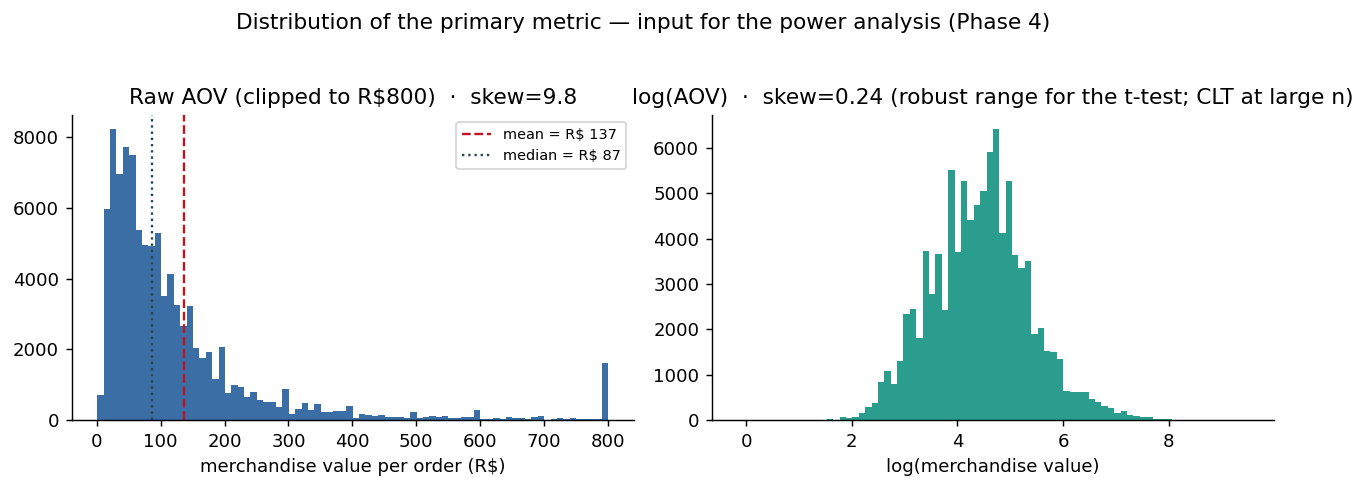

In [3]:
f2 = rj("fase2_resumen.json")
aov = f2["AOV_merch_value"]
logaov = f2["AOV_log_merch"]
print("PRIMARY METRIC — AOV (merchandise value per order)")
print(f"  n = {aov['n']:,}   mean = R$ {aov['mean']:.2f}   median = R$ {aov['median']:.2f}")
print(f"  CV = {aov['cv']:.3f}   skew = {aov['skew']:.1f}   excess kurtosis = {aov['kurtosis_excess']:.0f}")
print(f"  log(AOV): skew = {logaov['skew']:.2f}   kurtosis = {logaov['kurtosis_excess']:.2f}  (robust range)")
print(f"\n  {f2['orders_per_customer']['pct_customers_1_order']:.1f}% of customers with just 1 order "
      f"-> randomization unit ≈ analysis unit")
print("  Reading: AOV is highly skewed; at large n the mean is normal by the CLT -> Welch-t primary.")
display(Image(str(FIGURES / "f2_02_distribucion_aov.png")))

**Validity limitations** (`docs/02_data_understanding.md` §2.7): no real randomization or traffic
layer; declared injected effect; historical window of 2 years (not a 2-4 week experiment);
~3% repeat purchase -> no retention metric; single market.

---
## Phase 3 — Data Preparation

Cleaning aimed at the experimental question. Every step is traced.
Decisions: 2017-01/2018-08 window · review dedup by timestamp · **dedup to 1 order/customer**
(moves the AOV only -0.35%) · **p99.5 winsorization only for the significance test**.

In [4]:
display(pd.read_csv(TABLES / "fase3_transformaciones.csv"))

,paso,n_antes,n_despues,delta,justificacion
0,date_window,99441,99092,-349,"restrict to [2017-01-01, 2018-09-01) for reali..."
1,valid_statuses,99092,97905,-1187,"keep ['approved', 'delivered', 'invoiced', 'pr..."
2,orders_with_items,97905,97905,0,exclude orders with no order_items lines (they...
3,dedup_1_order_per_customer,97905,94703,-3202,keep each customer's first order -> randomizat...


,covariable,tipo,SMD,p_value,balanceada
0,n_items,continuous,-0.0036,0.5790,True
1,freight_value,continuous,0.0067,0.3046,True
2,customer_state,categorical (27 levels),0.0127,0.9185,True
3,cat_dominante,categorical (72 levels),0.0200,0.3203,True
4,payment_type,categorical (4 levels),0.0085,0.6227,True
5,mes_compra,categorical (20 levels),0.0153,0.6930,True


All |SMD| < 0.10: True   ·   no omnibus test significant: True
SRM check: control=47280 treatment=47423  chi2=0.216 p=0.642  ->  no SRM


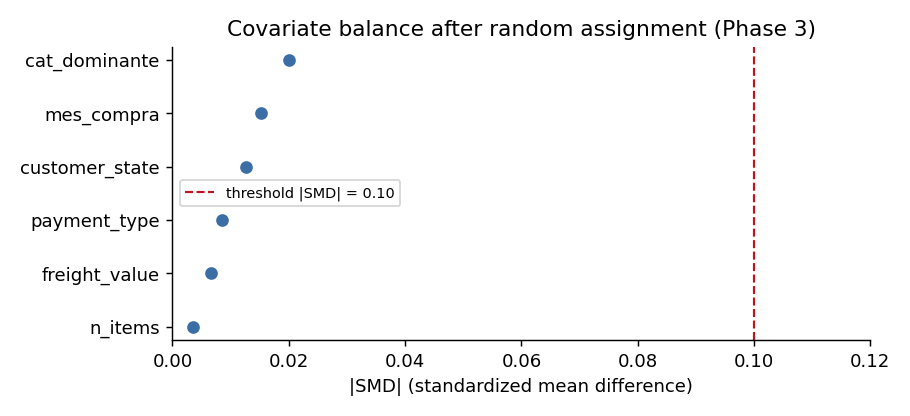

In [5]:
bal = pd.read_csv(TABLES / "fase3_balance.csv")
srm = pd.read_csv(TABLES / "fase3_srm.csv").iloc[0]
display(bal[["covariable", "tipo", "SMD", "p_value", "balanceada"]])
print(f"All |SMD| < 0.10: {bal['balanceada'].all()}   ·   no omnibus test significant: "
      f"{(bal['p_value'] >= 0.05).all()}")
print(f"SRM check: control={srm['n_control']} treatment={srm['n_treatment']}  "
      f"chi2={srm['chi2']:.3f} p={srm['p_value']:.3f}  ->  {srm['veredicto']}")
display(Image(str(FIGURES / "f3_01_balance.png")))

---
## Phase 4 — Modeling (statistical design of the experiment)

POWER ANALYSIS
  [raw         ] detectable MDE at 80% = +2.789%   power(ATE=+5%) = 1.0   mean lift (1000 sims) = 4.999%  (bias -0.001 pp)
  [winsor_p99.5] detectable MDE at 80% = +2.336%   power(ATE=+5%) = 1.0   mean lift (1000 sims) = 5.006%  (bias 0.006 pp)

  Power penalty from the diluted effect: -0.11 pp -> negligible (the AOV's natural variance, CV≈1.5, dominates).


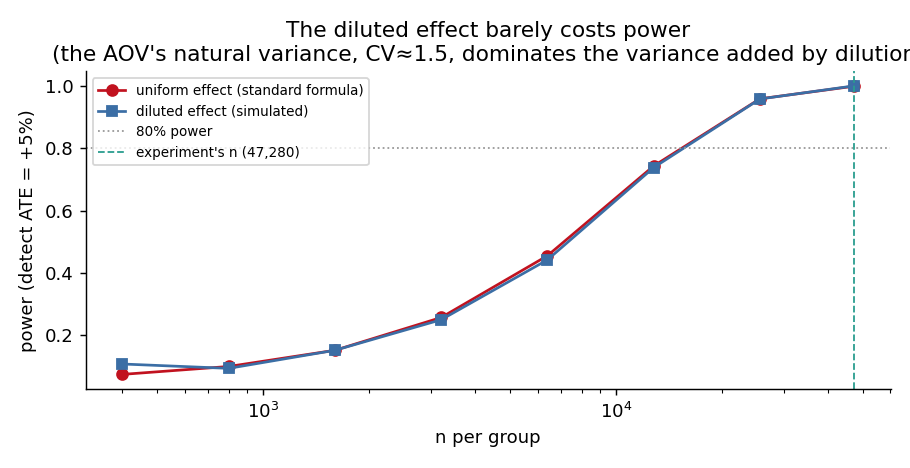

In [6]:
f4 = rj("fase4_resumen.json")
pw = f4["1_power_analysis"]
print("POWER ANALYSIS")
for k in ("raw", "winsor_p99.5"):
    r = pw[k]
    print(f"  [{k:12}] detectable MDE at 80% = +{r['mde_rel_detectable_80pct_pct']}%   "
          f"power(ATE=+5%) = {r['power_diluted_effect_+5pct_ATE']}   "
          f"mean lift (1000 sims) = {r['mean_estimated_lift_sim_pct']}%  (bias {r['estimator_bias_pp']} pp)")
print(f"\n  Power penalty from the diluted effect: "
      f"{pw['raw']['power_penalty_from_dilution_pp']} pp -> negligible "
      f"(the AOV's natural variance, CV≈1.5, dominates).")
display(Image(str(FIGURES / "f4_04_power_vs_n.png")))

ASSUMPTION CHECKS
  Normality of the raw data      : p = 0.0  (not normal, as expected)
  Normality of the mean (CLT)    : p = 0.8259  -> Welch-t valid
  Homoscedasticity WITHOUT effect: Levene p = 0.2048
  Homoscedasticity WITH effect   : Levene p = 1.64e-06  -> unequal variances under H1 -> use Welch, NOT Student


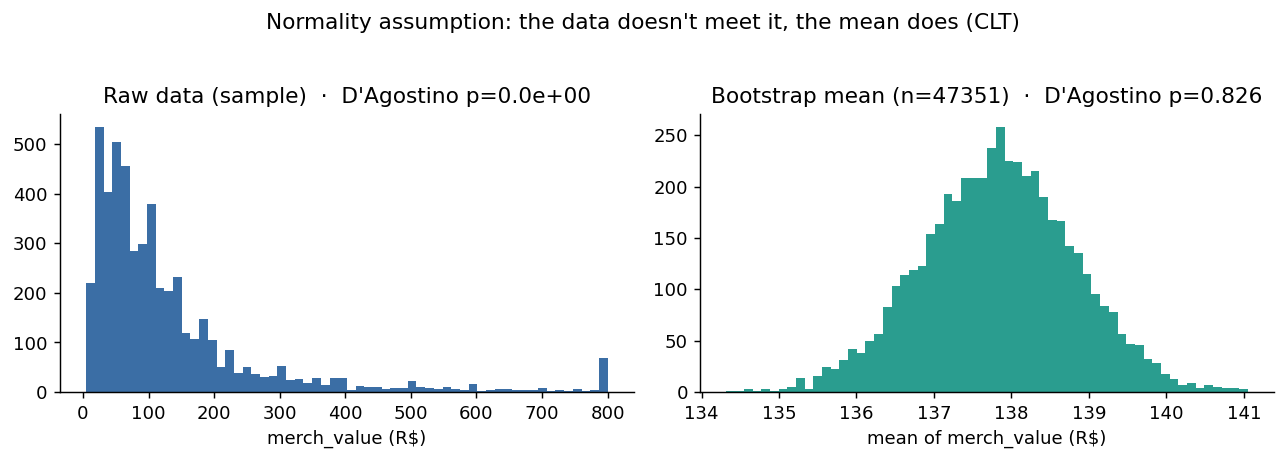

In [7]:
asm = f4["2_assumptions"]
print("ASSUMPTION CHECKS")
print(f"  Normality of the raw data      : p = {asm['normality_raw_data']['p']}  (not normal, as expected)")
print(f"  Normality of the mean (CLT)    : p = {asm['normality_bootstrap_mean']['p']}  -> Welch-t valid")
print(f"  Homoscedasticity WITHOUT effect: Levene p = {asm['homoscedasticity_no_effect']['p']}")
print(f"  Homoscedasticity WITH effect   : Levene p = {asm['homoscedasticity_diluted_effect']['p']}"
      f"  -> unequal variances under H1 -> use Welch, NOT Student")
display(Image(str(FIGURES / "f4_01_tcl_normalidad.png")))

A/A CALIBRATION  (2,000 random partitions, no effect)
  [merch_value   ] false positives = 0.050  (95% CI [0.04, 0.059])  ·  KS vs. uniform p = 0.527  ->  calibrated
  [merch_value_w ] false positives = 0.050  (95% CI [0.04, 0.06])  ·  KS vs. uniform p = 0.933  ->  calibrated
  [log_merch     ] false positives = 0.050  (95% CI [0.04, 0.06])  ·  KS vs. uniform p = 0.725  ->  calibrated


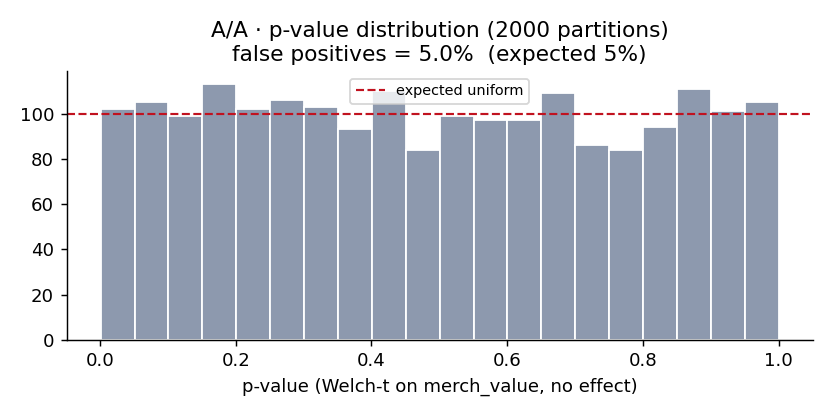

In [8]:
print("A/A CALIBRATION  (2,000 random partitions, no effect)")
for k, v in f4["3_aa_calibration"].items():
    print(f"  [{k:14}] false positives = {v['false_positive_rate_alpha_0.05']:.3f}  "
          f"(95% CI {L(v['CI95_rate'])})  ·  KS vs. uniform p = {v['KS_vs_uniform_p']:.3f}  ->  {v['verdict']}")
display(Image(str(FIGURES / "f4_02_aa_pvalores.png")))

A/B TEST  —  injected diluted effect (SEED=42)
  Welch · winsor AOV : +5.666%  95% CI [3.994, 7.337]%  ·  p = 3.095e-11
  Welch · raw AOV    : +6.111%  [4.091, 8.131]%
  bootstrap (10k)    : [4.048, 8.187]%
  the true effect (+5%) is within the CI: True

  GUARDRAILS (Benjamini-Hochberg):
    G1_review_score       BH-adjusted p = 0.804  ->  degraded: False
    G2_cancellation       BH-adjusted p = 0.609  ->  degraded: False
    G3_freight_value      BH-adjusted p = 0.609  ->  degraded: False
    G4_n_items            BH-adjusted p = 0.772  ->  degraded: False


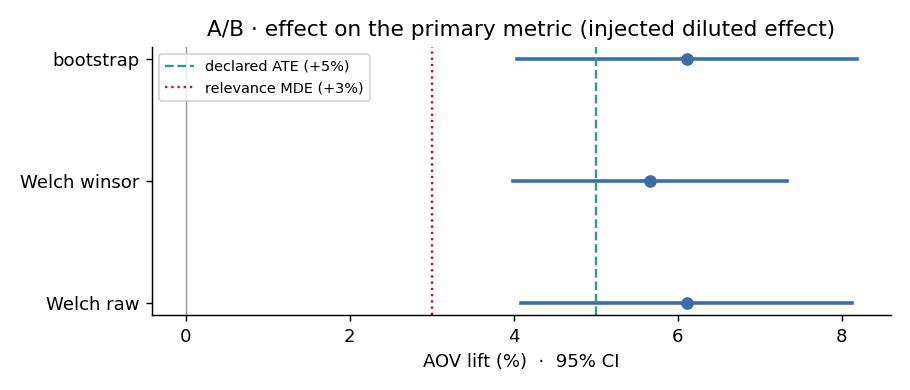

In [9]:
p = f4["4_ab_test"]["primary"]
print("A/B TEST  —  injected diluted effect (SEED=42)")
print(f"  Welch · winsor AOV : +{p['Welch_winsor_p99.5']['lift_rel_pct']}%  "
      f"95% CI {L(p['Welch_winsor_p99.5']['CI95_lift_pct'])}%  ·  p = {p['Welch_winsor_p99.5']['p_value']}")
print(f"  Welch · raw AOV    : +{p['Welch_raw']['lift_rel_pct']}%  {L(p['Welch_raw']['CI95_lift_pct'])}%")
print(f"  bootstrap (10k)    : {L(p['bootstrap_ratio']['CI95_lift_pct'])}%")
print(f"  the true effect (+5%) is within the CI: {p['Welch_winsor_p99.5']['ATE_5pct_in_CI']}")
print("\n  GUARDRAILS (Benjamini-Hochberg):")
for g, v in f4["4_ab_test"]["guardrails"].items():
    print(f"    {g:20}  BH-adjusted p = {v['p_adjusted_BH']:.3f}  ->  degraded: {v['significant_after_BH']}")
display(Image(str(FIGURES / "f4_03_ab_efecto.png")))

### Phase 4 · additional robustness (global audit improvements)

In [10]:
ms = f4["8_ab_multiseed"]
print("MULTI-SEED A/B (500 replicates: re-split + re-injection)")
for k in ("raw", "winsor_p99.5"):
    m = ms[k]
    print(f"  [{k:12}] mean lift = {m['mean_lift_pct']}%   bias = {m['bias_pp']} pp   "
          f"95% CI coverage of +5% = {m['CI95_coverage_of_+5pct']}")
print("  -> RAW is UNBIASED and has nominal coverage; winsorization introduces -0.36 pp of bias.")

gr = f4["6_guardrail_regression"]
print("\nREGRESSION INJECTED INTO G1 (two-gate rule: significant AND magnitude >= 0.05)")
for s in gr["scenarios"]:
    print(f"  injected {s['regression_injected_pts']:+.2f} pts -> p={s['p_value']:.1e}   "
          f"blocks (AND rule): {s['rule_AND_(significant_AND_magnitude)']}")
print("  -> at large n EVERYTHING is significant; the rule needs the magnitude gate.")

het = f4["7_heterogeneous_effect"]
print(f"\nVARIANT WITH A REAL HETEROGENEOUS EFFECT (concentrated below R$ {het['free_shipping_threshold_R$']:.0f})")
print(f"  lift within band = {het['lift_in_band_pct']}%   outside = {het['lift_outside_band_pct']}%   "
      f"interaction p = {het['p_interaction_near_threshold_HC3']}")
print("  -> the segment analysis DOES detect heterogeneity when it exists.")

cl = f4["9_clustered_se"]
print("\nALL ORDERS + CUSTOMER-CLUSTERED SE")
print(f"  lift = {cl['lift_pct_all_orders']}%  (dedup: {cl['lift_pct_dedup_1_order_per_customer_ref']}%)   "
      f"·  clustering inflates the SE by only {cl['SE_inflation_from_clustering_pct']}%")

MULTI-SEED A/B (500 replicates: re-split + re-injection)
  [raw         ] mean lift = 4.969%   bias = -0.031 pp   95% CI coverage of +5% = 0.942
  [winsor_p99.5] mean lift = 4.64%   bias = -0.36 pp   95% CI coverage of +5% = 0.92
  -> RAW is UNBIASED and has nominal coverage; winsorization introduces -0.36 pp of bias.

REGRESSION INJECTED INTO G1 (two-gate rule: significant AND magnitude >= 0.05)
  injected +0.00 pts -> p=8.0e-01   blocks (AND rule): False
  injected -0.03 pts -> p=1.2e-03   blocks (AND rule): False
  injected -0.05 pts -> p=2.8e-08   blocks (AND rule): False
  injected -0.08 pts -> p=1.6e-19   blocks (AND rule): True
  -> at large n EVERYTHING is significant; the rule needs the magnitude gate.

VARIANT WITH A REAL HETEROGENEOUS EFFECT (concentrated below R$ 150)
  lift within band = 7.05%   outside = 1.52%   interaction p = 2.14e-15
  -> the segment analysis DOES detect heterogeneity when it exists.

ALL ORDERS + CUSTOMER-CLUSTERED SE
  lift = 5.713%  (dedup: 5.666%) 

### Phase 4 · relevance MDE derived from a cost model

The +3% is not asserted: it is the *break-even* of the redesign (incremental margin = cost of ownership).

horizonte_payback_anios,1,2,3
pedidos_anio,,,
58700,34.196,21.243,16.925
250000,8.029,4.988,3.974
1000000,2.007,1.247,0.994
5000000,0.401,0.249,0.199
20000000,0.100,0.062,0.050


The +3% is valid for a marketplace with >= ~415,000 orders/year (2-year payback).


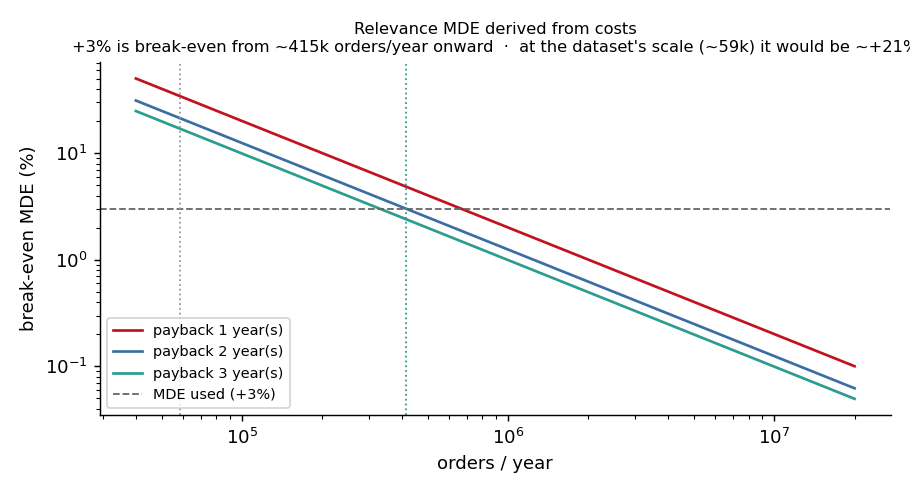

In [11]:
_mde = pd.read_csv(TABLES / "mde_cost_model.csv")
display(_mde.pivot(index="pedidos_anio", columns="horizonte_payback_anios", values="MDE_breakeven_pct"))
print("The +3% is valid for a marketplace with >= ~415,000 orders/year (2-year payback).")
display(Image(str(FIGURES / "f_mde_breakeven.png")))

---
## Phase 5 — Evaluation

In [12]:
f5 = rj("fase5_resumen.json")
prim, imp, anc = f5["1_primary_result"], f5["2_business_impact"], f5["3_ancova"]
print("SIGNIFICANCE vs RELEVANCE")
print(f"  Primary effect  : +{prim['lift_pct']}%   95% CI {L(prim['CI95_lift_pct'])}%   log10(p) = {prim['log10_p']}")
print(f"  Significant?    : {prim['significant']}")
print(f"  CI entirely above the +3% MDE?  : {prim['ci_entirely_above_MDE']}   ->  RELEVANT: {prim['relevant']}")
print(f"\n  ANCOVA (covariate adjustment): +{anc['adjusted']['lift_pct']}%  "
      f"95% CI {L(anc['adjusted']['ci95_pct'])}%  ·  SE -{anc['SE_reduction_pct']}%")
print("\nESTIMATED ECONOMIC IMPACT")
print(f"  Merchandise GMV uplift : +R$ {imp['uplift_GMV_annual_R$']:,}/year  "
      f"(CI [{imp['uplift_GMV_annual_CI95_R$'][0]:,}, {imp['uplift_GMV_annual_CI95_R$'][1]:,}])")
print(f"  ≈ +R$ {imp['uplift_marketplace_revenue_annual_R$_assuming_15pct_commission']:,}/year of commission (15%)")

SIGNIFICANCE vs RELEVANCE
  Primary effect  : +5.666%   95% CI [3.994, 7.337]%   log10(p) = -10.51
  Significant?    : True
  CI entirely above the +3% MDE?  : True   ->  RELEVANT: True

  ANCOVA (covariate adjustment): +5.193%  95% CI [3.709, 6.677]%  ·  SE -11.23%

ESTIMATED ECONOMIC IMPACT
  Merchandise GMV uplift : +R$ 456,084/year  (CI [321,514, 590,655])
  ≈ +R$ 68,413/year of commission (15%)


PRE-SPECIFIED SEGMENTS — log(AOV) interaction, HC3 Wald, + Benjamini-Hochberg
  cesta           raw p = 0.924   BH p = 0.924   heterogeneous: False
  payment_type    raw p = 0.377   BH p = 0.924   heterogeneous: False
  macro_region    raw p = 0.680   BH p = 0.924   heterogeneous: False
  trimestre       raw p = 0.794   BH p = 0.924   heterogeneous: False
  cat_grupo       raw p = 0.135   BH p = 0.676   heterogeneous: False

P-HACKING — 38 exploratory cuts (expected by chance ≈ 1.9)
  test_at_LEVEL_(mv_w)              nominal = 5   after BH = 3   after Bonferroni = 2
  test_at_LOG_(relative_effect)     nominal = 2   after BH = 0   after Bonferroni = 0
  -> on the wrong scale (level) the artifacts of the multiplicative effect survive
     Bonferroni; on the correct scale (log) nothing survives. Correcting does not save a bad estimand.


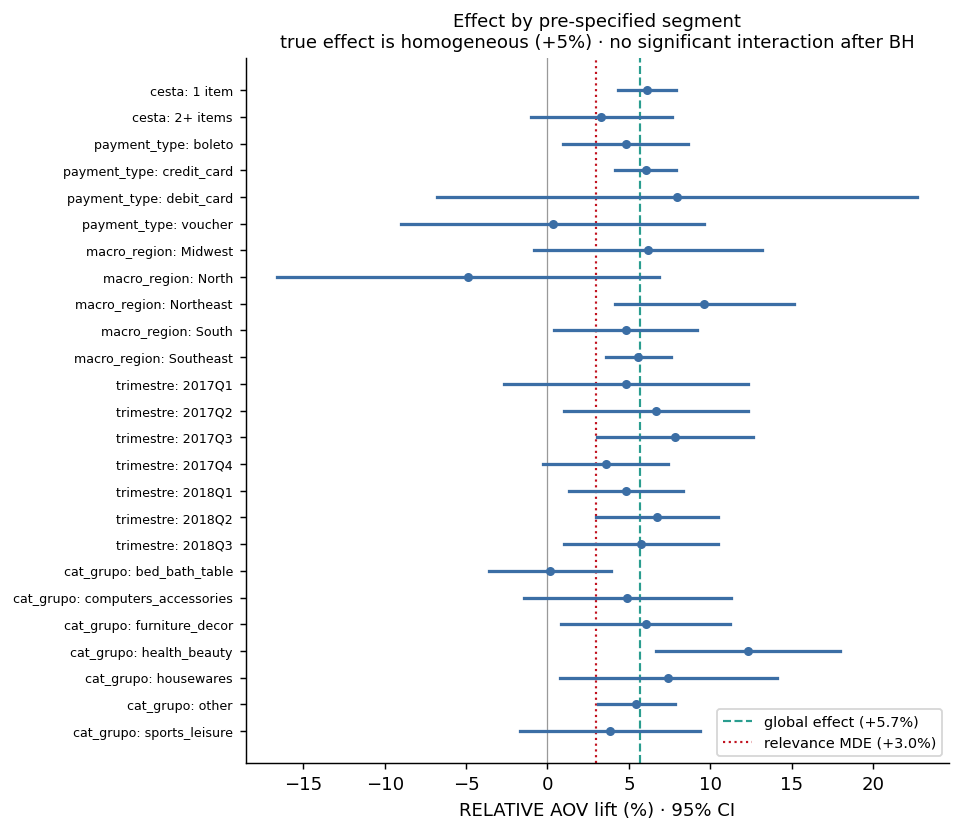

In [13]:
print("PRE-SPECIFIED SEGMENTS — log(AOV) interaction, HC3 Wald, + Benjamini-Hochberg")
for k, v in f5["4_segments"]["interaction_test"].items():
    print(f"  {k:14}  raw p = {v['p_raw']:.3f}   BH p = {v['p_BH']:.3f}   "
          f"heterogeneous: {v['heterogeneity_significant_after_BH']}")
print("\nP-HACKING — 38 exploratory cuts (expected by chance ≈ 1.9)")
ph = f5["5_p_hacking"]
for esc in ("test_at_LEVEL_(mv_w)", "test_at_LOG_(relative_effect)"):
    s = ph[esc]
    print(f"  {esc:32}  nominal = {s['nominal_p<0.05']['n']}   after BH = {s['after_BH']['n']}   "
          f"after Bonferroni = {s['after_Bonferroni']}")
print("  -> on the wrong scale (level) the artifacts of the multiplicative effect survive")
print("     Bonferroni; on the correct scale (log) nothing survives. Correcting does not save a bad estimand.")
display(Image(str(FIGURES / "f5_01_forest_segmentos.png")))

In [14]:
dec = f5["6_decision"]
print("=" * 60)
print(f"  PRODUCT DECISION:  {dec['decision']}")
print("=" * 60)
for j in dec["justification"]:
    print(f"  • {j}")
print("\n  Caveats:")
for cv in dec["caveats"]:
    print(f"  • {cv}")

  PRODUCT DECISION:  LAUNCH
  • Primary effect +5.67% (95% CI [3.99, 7.34]), log10(p) = -10.51 -> highly significant.
  • 95% CI entirely above the relevance MDE (+3.0%) -> relevant for the business.
  • No guardrail degraded (Phase 4, Benjamini-Hochberg).
  • Homogeneous effect across pre-specified segments (no interaction after BH).
  • Covariate-adjusted estimate (ANCOVA): +5.193% with SE 11.23% lower.
  • Estimated impact: +R$ 456,084/year of merchandise GMV (CI [321,514, 590,655]).

  Caveats:
  • The effect is synthetic and declared: this 'decision' validates the process, not a real finding.
  • The point estimate (+5.7%) exceeds the injected ATE (+5%) because of the split's baseline imbalance (+1.2%, not significant); the CI covers it.


---
## Phase 6 — Deployment

- **Executive summary (1 page, non-technical):** `docs/resumen_ejecutivo.md`
- **Repository README** · **LinkedIn post draft:** `docs/linkedin_post.md`
- **Per-phase documentation:** `docs/0X_*.md`
- **Audits:** `docs/auditoria_fase1_fase2.md` · `docs/auditoria_fase5.md` ·
  `docs/auditoria_global.md` (26 decisions + 6 improvements applied)

### Reproducibility

- Single entrypoint: **`python run_all.py`** (verifies invariants and exits with an error if something doesn't check out).
- Parameters in **`params.yaml`** (single source of truth, loaded by `src/config.py`).
- Tests: **`pytest`** (fast) · **`pytest -m slow`** (re-runs and checks idempotency).
- This notebook **only reads** `outputs/`; there is no parallel execution path.

### What this project demonstrates

1. **Complete experimental design**: hypothesis, single primary metric, two-gate guardrails,
   **MDE derived from a cost model**, decision rule — *before* looking at the data.
2. **A priori power analysis** + **empirical verification**: A/A (2,000 partitions, 5% false
   positives) and **multi-seed A/B** (500, unbiased estimator on raw data).
3. **Assumption checks** that change the chosen test (heteroscedasticity under H1 → Welch).
4. **Statistical significance vs. business relevance**, with impact in R$.
5. **P-hacking control**: pre-specification, multiplicity correction, and the demonstration that
   the wrong scale for the estimand fabricates findings that not even Bonferroni removes.
6. **Methodological honesty**: the effect is synthetic and declared; the project validates the *process*.